# Phase 1: Data Exploration and Analysis
## The Wisconsin Breast Cancer Dataset

**Context:**
We are building a Multilayer Perceptron (MLP) from scratch to perform binary classification. Our dataset consists of 32 columns (features computed from a digitized image of a fine needle aspirate of a breast mass) and a target label: `Diagnosis` (M = Malignant, B = Benign).

**Objective:**
Before we initialize weights, define a network architecture, or calculate gradients, we must thoroughly understand our data. Neural networks are essentially pattern matchers shaped by the mathematical landscape of the input data. In this phase, we will inspect the data integrity (missing values, types) and analyze the target class distribution. Understanding the baseline distribution is structurally critical for properly interpreting our network's loss and accuracy metrics later.

In [7]:
# ==========================================
# 1. Library Ingestion & Data Loading
# ==========================================
# DEFENSE PREPARATION:
# We strictly limit our imports to basic mathematical and data-handling libraries.
# - pandas: Exclusively for reading the CSV and basic descriptive data structures.
# - numpy: The backbone for later mathematical operations (matrix multiplication, vectors).
# - matplotlib/seaborn: For visual analysis of the underlying data distributions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path (assuming the CSV acts as your raw data in the data/ directory)
data_path = "data/data.csv"

try:
    # Adding header=None because the Wisconsin dataset raw CSV lacks a header row.
    df = pd.read_csv(data_path, header=None)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find the dataset at {data_path}. Please ensure the file exists.")

Dataset loaded successfully.


In [8]:
# ==========================================
# 2. Data Inspection
# ==========================================
# DEFENSE PREPARATION:
# Why do we run info() and head() before anything else?
# 1. Data Type Verification: Our MLP requires purely numerical input for matrix 
#    multiplication. If any features are strings/objects, they will break the forward pass.
# 2. NaN validation: A single NaN value will propagate through the network during the 
#    forward pass, rendering all subsequent weights and gradients as NaN.

# Display the structural info (column names, non-null counts, datatypes)
print("--- Dataset Structure ---")
df.info()

# Display the first 5 rows to visually verify the feature values and target column
print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Structure ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    int64  
 1   1       569 non-null    str    
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    float64
 17  17      569 non-null    float64
 18  18      569 non-null    float64
 19  19      569 non-null    float64
 20  20      569 non-null    float64
 21  21      569 non-null    

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# ==========================================
# 3. Class Distribution Visualization
# ==========================================
# DEFENSE PREPARATION:
# We need to visualize the exact count of Malignant (M) vs Benign (B) cases.
# This directly informs us about data imbalance, which dictates how we interpret 
# our eventual accuracy metric.

# Looking at the raw data structure, since there is no header, the target label 
# (M or B) is located in the second column (index 1).
target_col = 1

# Calculate raw counts
class_counts = df[target_col].value_counts()


In [10]:

print("Raw Class Counts:")
print(class_counts)


Raw Class Counts:
1
B    357
M    212
Name: count, dtype: int64


/var/folders/lt/0wgz0hyd67z6zxh62hn6qff40000gn/T/ipykernel_12942/3913713225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target_col], palette="Set2")


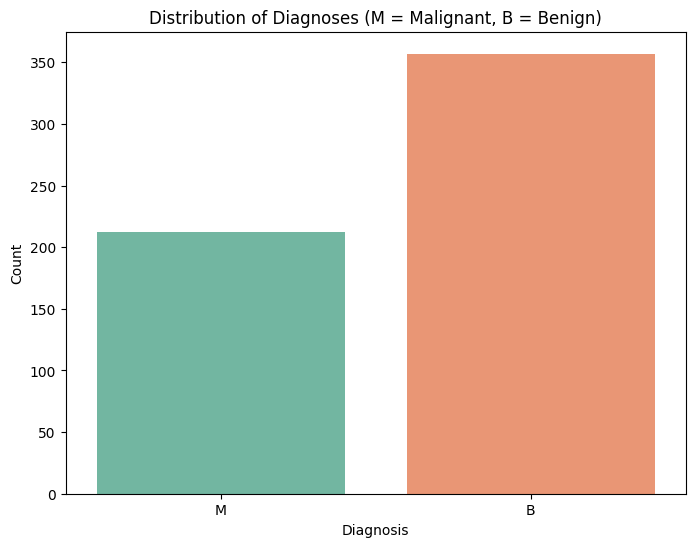

In [11]:

# Plotting the distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=df[target_col], palette="Set2")
plt.title("Distribution of Diagnoses (M = Malignant, B = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


In [12]:

# Calculate and display the percentage split
total_samples = len(df)
benign_pct = (class_counts['B'] / total_samples) * 100
malignant_pct = (class_counts['M'] / total_samples) * 100

print(f"Percentage Split -> Benign: {benign_pct:.2f}%, Malignant: {malignant_pct:.2f}%")

Percentage Split -> Benign: 62.74%, Malignant: 37.26%


That 62.74% Benign to 37.26% Malignant split is a classic "real-world" scenario. It’s not perfectly balanced (50/50), but it’s not so skewed (99/1) that we need complex oversampling.

However, from a defense perspective, this is a trap you must be ready to explain: If your model does nothing but guess "Benign" for every single patient, it would be 63% accurate while being 100% useless at catching cancer. This is exactly why your project requirements insist on Binary Cross-Entropy and Validation Sets—to ensure the model actually learns the features of malignancy, not just the frequency of the labels.